In [ ]:
import torch
from torch.utils.data.dataset import TensorDataset


tensors = torch.load('dinov3_activations.pth')
print(tensors.shape)

torch.Size([2461940, 768])


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
import torch

def visualize_highdim_gaussian(means, samples, n_components=2):
    """
    Visualize a high-dimensional Gaussian distribution by projecting it into 2D or 3D using PCA
    and plotting a density estimate (KDE based on means only).
    """

    # Combine for PCA projection (so both are in the same reduced space)
    pca = PCA(n_components=n_components)
    joined = torch.cat((means, samples), dim=0)
    reduced_all = pca.fit_transform(joined.detach().cpu().numpy())
    reduced_means = reduced_all[:len(means)]
    reduced_samples = reduced_all[len(means):]

    if n_components == 2:
        # KDE from means only
        x, y = reduced_means[:, 0], reduced_means[:, 1]
        kde = gaussian_kde(np.vstack([x, y]))

        # Range must include both means and samples
        all_points = np.vstack([reduced_means, reduced_samples])
        margin = 0.1
        x_min, x_max = all_points[:, 0].min(), all_points[:, 0].max()
        y_min, y_max = all_points[:, 1].min(), all_points[:, 1].max()
        dx, dy = x_max - x_min, y_max - y_min
        x_min, x_max = x_min - margin * dx, x_max + margin * dx
        y_min, y_max = y_min - margin * dy, y_max + margin * dy

        xi, yi = np.mgrid[x_min:x_max:300j, y_min:y_max:300j]
        zi = kde(np.vstack([xi.ravel(), yi.ravel()]))

        # Plot density and points
        plt.figure(figsize=(8, 6))
        plt.pcolormesh(xi, yi, zi.reshape(xi.shape), shading='auto', cmap='viridis')
        plt.scatter(reduced_means[:, 0], reduced_means[:, 1], s=5, alpha=0.6, color='white', label='Means')
        plt.scatter(reduced_samples[:, 0], reduced_samples[:, 1], color='red', label='Samples', edgecolors='black')
        plt.title(f"{means.shape[1]}D Gaussian projected to 2D via PCA (KDE from means only)")
        plt.xlabel("Principal Component 1")
        plt.ylabel("Principal Component 2")
        plt.colorbar(label='Density (from means)')
        plt.legend()
        plt.tight_layout()
        plt.show()

    elif n_components == 3:
        from mpl_toolkits.mplot3d import Axes3D
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(reduced_means[:, 0], reduced_means[:, 1], reduced_means[:, 2],
                   s=5, alpha=0.3, label='Means')
        ax.scatter(reduced_samples[:, 0], reduced_samples[:, 1], reduced_samples[:, 2],
                   color='red', label='Samples')
        ax.set_title(f"{means.shape[1]}D Gaussian projected to 3D via PCA (no KDE)")
        ax.legend()
        plt.show()

    else:
        raise ValueError("n_components must be 2 or 3")



torch.Size([50, 100]) torch.Size([1024, 100])


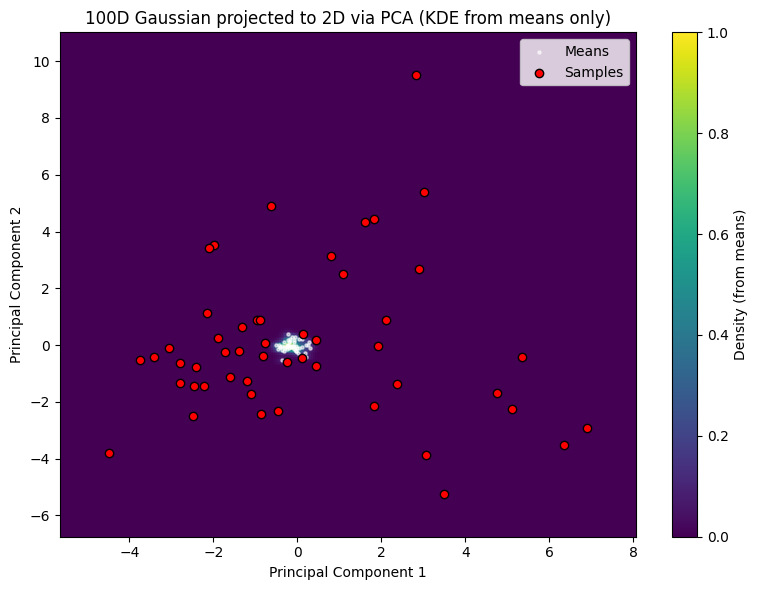

In [7]:
import torch

means, samples = torch.load("error.pth")
print(means.shape, samples.shape)

visualize_highdim_gaussian(means, samples[:50])